Using device: cpu

Total Samples: 10689

Classes Found:
['agitation', 'clustering', 'normal', 'other']
0 agitation
1 clustering
2 normal
3 other

Training FishCNN...

Epoch 1/30 Loss=1.0710
Epoch 2/30 Loss=0.8925
Epoch 3/30 Loss=0.7940
Epoch 4/30 Loss=0.7317
Epoch 5/30 Loss=0.7079
Epoch 6/30 Loss=0.6560
Epoch 7/30 Loss=0.6652
Epoch 8/30 Loss=0.6196
Epoch 9/30 Loss=0.6242
Epoch 10/30 Loss=0.6180
Epoch 11/30 Loss=0.5925
Epoch 12/30 Loss=0.5639
Epoch 13/30 Loss=0.5595
Epoch 14/30 Loss=0.5554
Epoch 15/30 Loss=0.5390
Epoch 16/30 Loss=0.5250
Epoch 17/30 Loss=0.5214
Epoch 18/30 Loss=0.5107
Epoch 19/30 Loss=0.5564
Epoch 20/30 Loss=0.5374
Epoch 21/30 Loss=0.5448
Epoch 22/30 Loss=0.5364
Epoch 23/30 Loss=0.5484
Epoch 24/30 Loss=0.5623
Epoch 25/30 Loss=0.4923
Epoch 26/30 Loss=0.4893
Epoch 27/30 Loss=0.4825
Epoch 28/30 Loss=0.4753
Epoch 29/30 Loss=0.4908
Epoch 30/30 Loss=0.4492

Evaluating...



FISHCNN RESULTS

Training Time: 1603.9 s
Inference Time: 5.1504 ms/sample
Accuracy: 0.7423
Precision: 0.

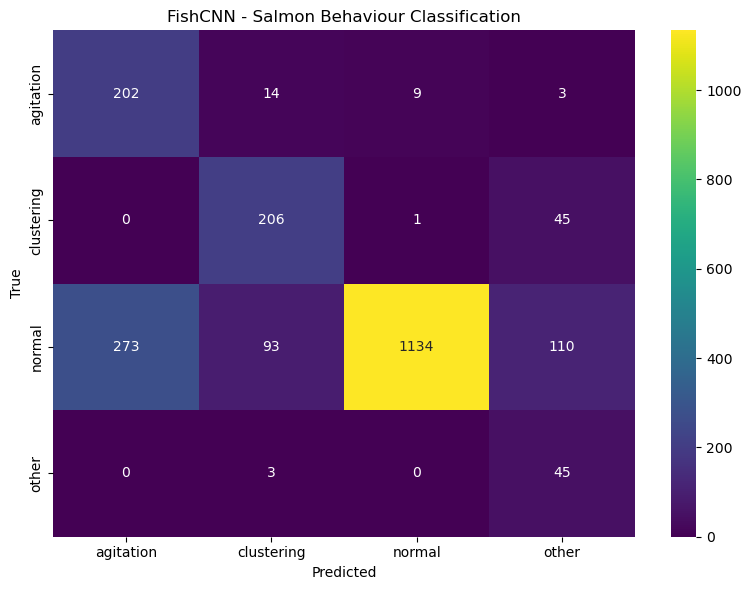


Saved:
fishcnn_salmon_results.csv
fishcnn_salmon.pth
fishcnn_confusion_matrix.png


In [2]:
import os
import time
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "/media/feliciano/Aux/AI_AFS_DATASET/behavior_dataset"

SAMPLE_RATE = 16000
N_MELS = 128
FMAX = 4000

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3

# FORCE CPU IF CUDA IS BROKEN
DEVICE = "cpu"

print("Using device:", DEVICE)

# =====================================================
# FishCNN (Sea Bream Architecture)
# =====================================================

class FishCNN(nn.Module):

    def __init__(self, num_classes=4):

        super(FishCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            1,
            32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.gap = nn.AdaptiveAvgPool2d(
            (8, 8)
        )

        self.fc1 = nn.Linear(
            64 * 8 * 8,
            128
        )

        self.dropout = nn.Dropout(
            0.3
        )

        self.fc2 = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.pool1(
            torch.relu(
                self.bn1(
                    self.conv1(x)
                )
            )
        )

        x = self.pool2(
            torch.relu(
                self.bn2(
                    self.conv2(x)
                )
            )
        )

        x = self.gap(x)

        x = torch.flatten(
            x,
            1
        )

        x = torch.relu(
            self.fc1(x)
        )

        x = self.dropout(x)

        x = self.fc2(x)

        return x

# =====================================================
# MEL EXTRACTION
# =====================================================

def extract_mel(path):

    signal, sr = librosa.load(
        path,
        sr=SAMPLE_RATE,
        mono=True
    )

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        fmax=FMAX
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db.astype(
        np.float32
    )

# =====================================================
# LABEL MAPPING
# =====================================================

def map_label_from_path(path):

    p = path.lower()

    if "normal" in p:
        return "normal"

    if "clustering" in p:
        return "clustering"

    if "agitation" in p:
        return "agitation"

    if "other" in p:
        return "other"

    return None

# =====================================================
# LOAD DATASET
# =====================================================

files = []
labels = []

for root, dirs, fs in os.walk(DATASET_PATH):

    for f in fs:

        if f.endswith(".wav"):

            path = os.path.join(
                root,
                f
            )

            label = map_label_from_path(
                root
            )

            if label is not None:

                files.append(path)
                labels.append(label)

print("\nTotal Samples:", len(files))

print("\nClasses Found:")
print(sorted(set(labels)))

# =====================================================
# LABEL ENCODING
# =====================================================

encoder = LabelEncoder()

y = encoder.fit_transform(
    labels
)

for idx, cls in enumerate(
    encoder.classes_
):
    print(idx, cls)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

train_files, test_files, y_train, y_test = train_test_split(
    files,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# DATASET
# =====================================================

class MelDataset(Dataset):

    def __init__(
        self,
        filepaths,
        labels
    ):

        self.filepaths = filepaths
        self.labels = labels

    def __len__(self):

        return len(
            self.filepaths
        )

    def __getitem__(
        self,
        idx
    ):

        mel = extract_mel(
            self.filepaths[idx]
        )

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return mel, label

# =====================================================
# DATALOADERS
# =====================================================

train_ds = MelDataset(
    train_files,
    y_train
)

test_ds = MelDataset(
    test_files,
    y_test
)

train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dl = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =====================================================
# CLASS WEIGHTS
# =====================================================

class_counts = np.bincount(
    y_train
)

weights = (
    len(y_train)
    /
    (
        len(class_counts)
        * class_counts
    )
)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(DEVICE)

# =====================================================
# MODEL
# =====================================================

model = FishCNN(
    num_classes=4
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# =====================================================
# TRAINING
# =====================================================

print("\nTraining FishCNN...\n")

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for mel, label in train_dl:

        mel = mel.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()

        output = model(
            mel
        )

        loss = criterion(
            output,
            label
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss={running_loss/len(train_dl):.4f}"
    )

train_time = (
    time.time()
    - start_time
)

# =====================================================
# EVALUATION
# =====================================================

print("\nEvaluating...\n")

model.eval()

y_true = []
y_pred = []

start_inf = time.time()

with torch.no_grad():

    for mel, label in test_dl:

        mel = mel.to(DEVICE)

        outputs = model(
            mel
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            label.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

total_inf = (
    time.time()
    - start_inf
)

inf_per_sample = (
    total_inf
    / len(test_ds)
)

# =====================================================
# METRICS
# =====================================================

acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred,
    average="macro"
)

rec = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

cm = confusion_matrix(
    y_true,
    y_pred
)

# =====================================================
# RESULTS
# =====================================================

print("\n")
print("=" * 80)
print("FISHCNN RESULTS")
print("=" * 80)

print(
    "\nTraining Time:",
    round(train_time, 2),
    "s"
)

print(
    "Inference Time:",
    round(
        inf_per_sample * 1000,
        4
    ),
    "ms/sample"
)

print(
    "Accuracy:",
    round(acc, 4)
)

print(
    "Precision:",
    round(prec, 4)
)

print(
    "Recall:",
    round(rec, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

print(
    "\nClassification Report\n"
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

print(
    "\nConfusion Matrix\n"
)

print(cm)

# =====================================================
# SAVE RESULTS
# =====================================================

results = pd.DataFrame([{

    "Model": "FishCNN",

    "Accuracy": acc,

    "Precision": prec,

    "Recall": rec,

    "F1": f1,

    "Training_Time_s": train_time,

    "Inference_ms": (
        inf_per_sample * 1000
    )
}])

results.to_csv(
    "fishcnn_salmon_results.csv",
    index=False
)

torch.save(
    model.state_dict(),
    "fishcnn_salmon.pth"
)

# =====================================================
# PLOT CONFUSION MATRIX
# =====================================================

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "FishCNN - Salmon Behaviour Classification"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.tight_layout()

plt.savefig(
    "fishcnn_confusion_matrix.png",
    dpi=300
)

plt.show()

print("\nSaved:")
print("fishcnn_salmon_results.csv")
print("fishcnn_salmon.pth")
print("fishcnn_confusion_matrix.png")